# 02 — Feature Engineering

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
except NameError:
    ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
sys.path.insert(0, ROOT)
os.makedirs(os.path.join(ROOT, "outputs"), exist_ok=True)

from src.data_utils import load_raw
from src.feature_engineering import build_features, get_feature_groups

In [2]:
transactions, identity = load_raw(os.path.join(ROOT, "data", "raw"))
df = build_features(transactions, identity=identity)
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")

Rows: 590,540 | Columns: 462


In [3]:
groups = get_feature_groups()
rows = []
for name, cols in groups.items():
    present = [c for c in cols if c in df.columns]
    rows.append({"group": name, "features_present": len(present), "features": ", ".join(present[:5])})
feat_summary = pd.DataFrame(rows)
display(feat_summary)

,group,features_present,features
0,device,3,"unique_cards_on_device, unique_devices_for_car..."
1,email,3,"email_is_highrisk, email_domain_txn_count, ema..."
2,velocity,7,"w1h_txn_count, w6h_txn_count, w24h_txn_count, ..."
3,behavioral,5,"amt_zscore_from_card_mean, amt_ratio_to_median..."
4,time,4,"hour_of_day, day_of_week, is_night_txn, is_wee..."
5,network,3,"cards_at_address, address_is_shared, cards_wit..."


In [4]:
engineered = [c for c in df.columns if c not in transactions.columns]
sample = df[engineered + ["isFraud"]].describe().T
display(sample.head(15))

,count,mean,std,min,25%,50%,75%,max
id_01,144233.0,-10.170502,14.347949,-100.0,-10.0,-5.0,-5.0,0.0
id_02,140872.0,174716.584708,159651.816856,1.0,67992.0,125800.5,228749.0,999595.0
id_03,66324.0,0.060189,0.598231,-13.0,0.0,0.0,0.0,10.0
id_04,66324.0,-0.058938,0.701015,-28.0,0.0,0.0,0.0,0.0
id_05,136865.0,1.615585,5.249856,-72.0,0.0,0.0,1.0,52.0
id_06,136865.0,-6.698710,16.491104,-100.0,-6.0,0.0,0.0,0.0
id_07,5155.0,13.285354,11.384207,-46.0,5.0,14.0,22.0,61.0
id_08,5155.0,-38.600388,26.084899,-100.0,-48.0,-34.0,-23.0,0.0
id_09,74926.0,0.091023,0.983842,-36.0,0.0,0.0,0.0,25.0
id_10,74926.0,-0.301124,2.789446,-100.0,0.0,0.0,0.0,0.0


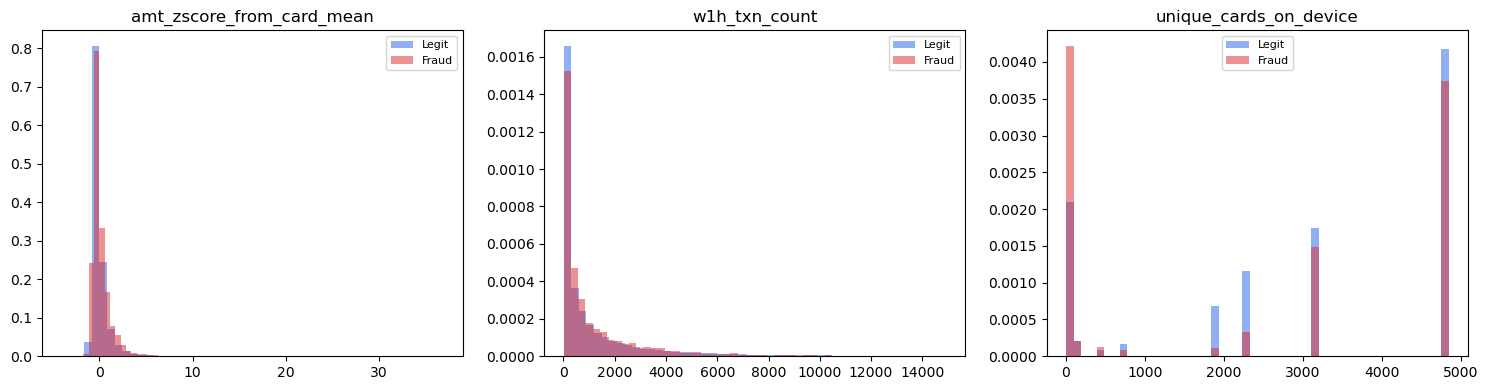

Saved C:\Users\Lenovo\OneDrive\github_projects\fraud-detection-ml\outputs\feature_engineering_distributions.png


In [5]:
plot_cols = [c for c in ["amt_zscore_from_card_mean", "w1h_txn_count", "unique_cards_on_device"] if c in df.columns]
if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 4))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        for label, color in [(0, "#2563EB"), (1, "#DC2626")]:
            subset = df.loc[df["isFraud"] == label, col].dropna()
            ax.hist(subset, bins=50, alpha=0.5, density=True, label="Fraud" if label else "Legit", color=color)
        ax.set_title(col)
        ax.legend(fontsize=8)
    plt.tight_layout()
    out = os.path.join(ROOT, "outputs", "feature_engineering_distributions.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")